# Entraînement CNN — Reconnaissance de kana (hiragana + katakana)

96 classes (48 hiragana + 48 katakana), dataset généré à partir de polices japonaises.

## 1. Imports & configuration

In [1]:
import json
import os
import random
from pathlib import Path

import numpy as np
import scipy.ndimage as ndi
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

# Police japonaise pour matplotlib (macOS)
matplotlib.rcParams["font.family"] = "Hiragino Sans"

# Seeds fixes pour reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Config
DATA_DIR = Path("data")
MODELS_DIR = Path("models")
PLOTS_DIR = Path("plots")
MODELS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

NUM_CLASSES = 96
IMG_SIZE = 28
BATCH_SIZE = 64
EPOCHS = 1000  # on laisse tourner toute la nuit, early stopping coupera

print(f"TensorFlow {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow 2.21.0
GPU: []


## 2. Chargement des données

In [2]:
# Charger le dataset et les labels
dataset = np.load(DATA_DIR / "kana_dataset.npz")
images = dataset["images"]  # (N, 28, 28) uint8
labels = dataset["labels"]  # (N,) uint8

with open(DATA_DIR / "labels.json") as f:
    label_info = json.load(f)

# Charger les indices de split
splits = np.load(DATA_DIR / "split_indices.npz")
train_idx = splits["train_idx"]
val_idx = splits["val_idx"]
test_idx = splits["test_idx"]

print(f"Dataset total : {len(images)} images, {len(np.unique(labels))} classes")
print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

Dataset total : 9312 images, 96 classes
Train: 6518 | Val: 1397 | Test: 1397


## 3. Preprocessing & split

X_train: (6518, 28, 28, 1) | X_val: (1397, 28, 28, 1) | X_test: (1397, 28, 28, 1)
Pixel range: [0.00, 1.00]

Soft labels — paires confondables :
  へ (hiragana, idx 28) ↔ ヘ (katakana, idx 76)


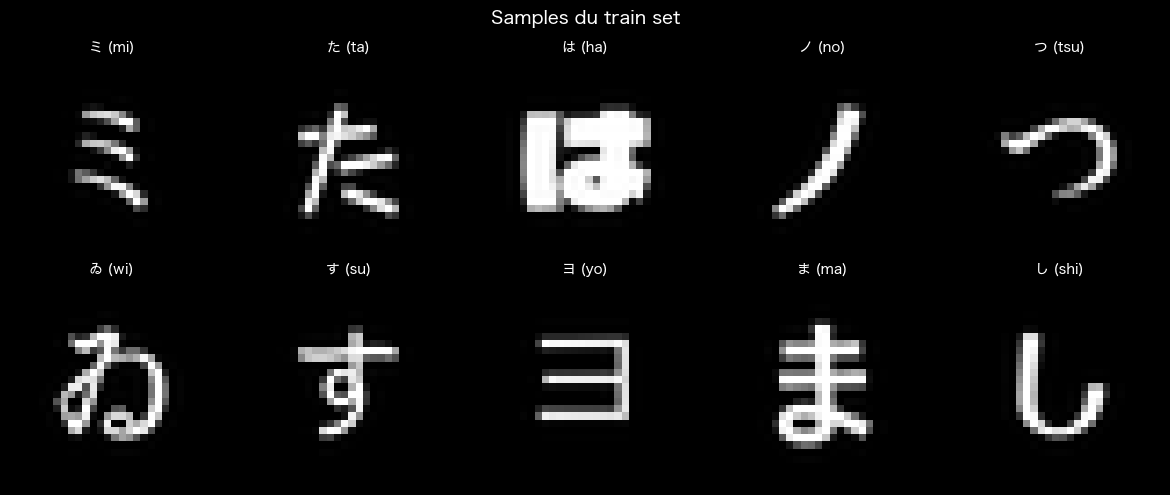

In [3]:
# Normaliser [0, 255] → [0, 1] et ajouter la dimension channel
X = images.astype(np.float32) / 255.0
X = X[..., np.newaxis]  # (N, 28, 28, 1)
y = labels.astype(np.int32)

# Split
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")
print(f"Pixel range: [{X_train.min():.2f}, {X_train.max():.2f}]")

# --- Soft labels pour les paires visuellement identiques ---
# へ (hiragana, idx 28) et ヘ (katakana, idx 76) sont indiscernables en pixels.
# On distribue la probabilité 50/50 pour ne pas pénaliser le modèle.
CONFUSABLE_PAIRS = [(28, 76)]  # へ ↔ ヘ

def to_soft_labels(y, num_classes=NUM_CLASSES, pairs=CONFUSABLE_PAIRS):
    """Labels entiers → soft one-hot. Paires confondables partagent 50/50."""
    n = len(y)
    soft = np.zeros((n, num_classes), dtype=np.float32)
    soft[np.arange(n), y] = 1.0
    for a, b in pairs:
        mask_a = y == a
        mask_b = y == b
        for mask in (mask_a, mask_b):
            soft[mask, a] = 0.5
            soft[mask, b] = 0.5
    return soft

y_train_soft = to_soft_labels(y_train)
y_val_soft = to_soft_labels(y_val)

print(f"\nSoft labels — paires confondables :")
for a, b in CONFUSABLE_PAIRS:
    ia, ib = label_info[a], label_info[b]
    print(f"  {ia['kana']} ({ia['type']}, idx {a}) ↔ {ib['kana']} ({ib['type']}, idx {b})")

# Aperçu : 10 samples aléatoires du train set
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_train), 10, replace=False)
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(X_train[idx, :, :, 0], cmap="gray")
    info = label_info[y_train[idx]]
    ax.set_title(f"{info['kana']} ({info['romaji']})", fontsize=10)
    ax.axis("off")
plt.suptitle("Samples du train set", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Data augmentation (on the fly)

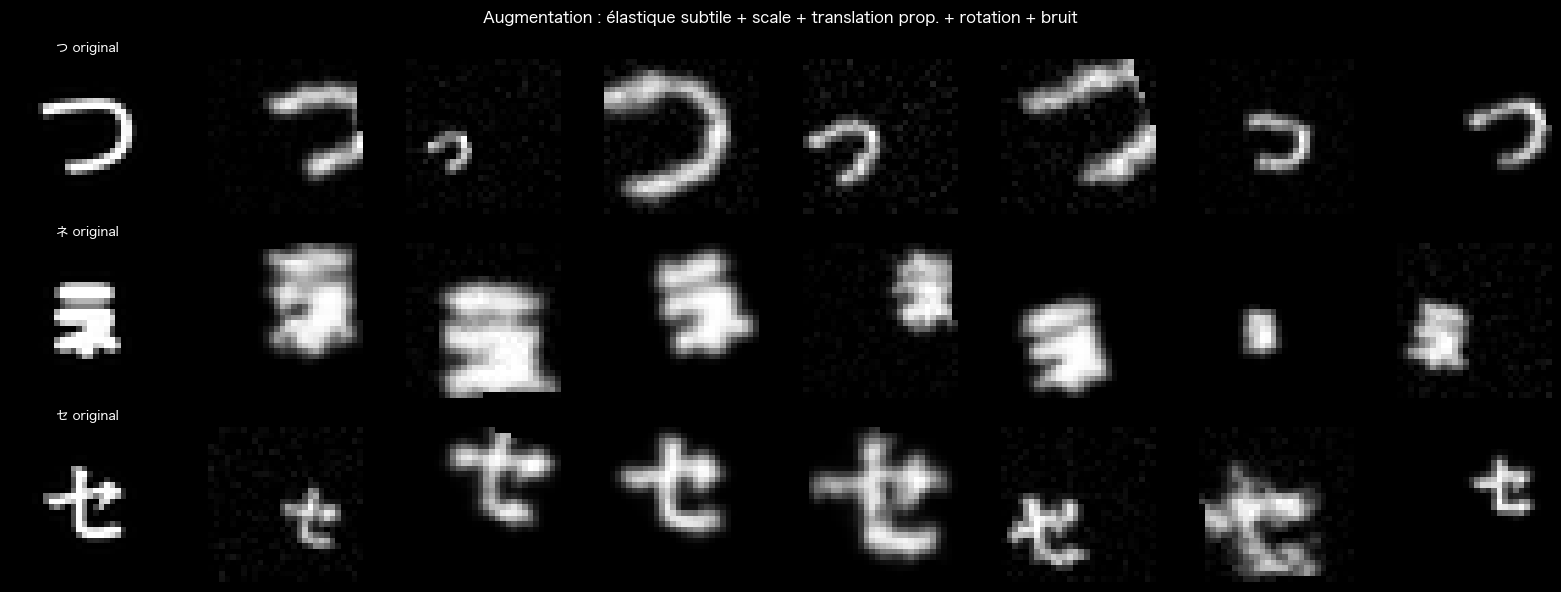

In [4]:
def elastic_distortion(image, alpha=3.0, sigma=0.7):
    """Distorsion élastique non-linéaire continue (Simard et al. 2003)."""
    shape = image.shape[:2]
    dx = ndi.gaussian_filter(np.random.randn(*shape), sigma) * alpha
    dy = ndi.gaussian_filter(np.random.randn(*shape), sigma) * alpha

    y, x = np.meshgrid(np.arange(shape[0]), np.arange(shape[1]), indexing="ij")
    coords = [np.clip(y + dy, 0, shape[0] - 1), np.clip(x + dx, 0, shape[1] - 1)]
    return ndi.map_coordinates(image, coords, order=1, mode="constant").astype(np.float32)


def pad_or_crop(img, size=28):
    """Force une image à exactement size×size."""
    h, w = img.shape[:2]
    if h > size:
        s = (h - size) // 2
        img = img[s:s + size, :]
    if w > size:
        s = (w - size) // 2
        img = img[:, s:s + size]
    h, w = img.shape[:2]
    if h < size or w < size:
        ph = (size - h + 1) // 2
        pw = (size - w + 1) // 2
        img = np.pad(img, ((ph, size - h - ph), (pw, size - w - pw)), mode="constant")
    return img


def recenter_content(img, size=28, threshold=0.05):
    """Recentre le contenu non-noir dans un canvas size×size."""
    mask = img > threshold
    if not mask.any():
        return img
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    cropped = img[rmin:rmax + 1, cmin:cmax + 1]
    return pad_or_crop(cropped, size)


def augment_batch(images, labels):
    """Augmentation on the fly — distorsion localisée subtile + translation proportionnelle."""
    batch_size = len(images)
    augmented = np.empty_like(images)

    for i in range(batch_size):
        img = images[i, :, :, 0].copy()

        # 0. Recentrer le contenu avant toute transformation
        img = recenter_content(img, 28)

        # 1. Distorsion élastique — subtile, légèrement localisée
        if np.random.random() < 0.9:
            alpha = np.random.uniform(0.6, 1.2)
            sigma = np.random.uniform(0.4, 0.7)
            img = elastic_distortion(img, alpha=alpha, sigma=sigma)

        # 2. Scale (zoom in/out)
        zoom_factor = np.random.uniform(0.4, 1.6)
        img = ndi.zoom(img, zoom_factor, order=1, mode="constant")
        img = pad_or_crop(img, 28)

        # 3. Translation proportionnelle au zoom
        max_shift_frac = min(0.30 / zoom_factor, 0.40)
        shift_y = np.random.uniform(-max_shift_frac, max_shift_frac) * 28
        shift_x = np.random.uniform(-max_shift_frac, max_shift_frac) * 28
        img = ndi.shift(img, [shift_y, shift_x], order=1, mode="constant")

        # 4. Rotation modérée
        angle = np.random.uniform(-20, 20)
        img = ndi.rotate(img, angle, reshape=False, order=1, mode="constant")

        # 5. Bruit léger (40% de chance)
        if np.random.random() < 0.4:
            noise = np.random.normal(0, np.random.uniform(0.01, 0.04), img.shape)
            img = np.clip(img + noise, 0, 1)

        augmented[i, :, :, 0] = img

    return augmented, labels


# --- Aperçu ---
fig, axes = plt.subplots(3, 8, figsize=(16, 6))

for row in range(3):
    sample = X_train[row * 100: row * 100 + 1]
    info = label_info[y_train[row * 100]]
    axes[row, 0].imshow(sample[0, :, :, 0], cmap="gray")
    axes[row, 0].set_title(f"{info['kana']} original", fontsize=9)
    axes[row, 0].axis("off")

    for col in range(1, 8):
        aug, _ = augment_batch(sample, None)
        axes[row, col].imshow(aug[0, :, :, 0], cmap="gray")
        axes[row, col].axis("off")

plt.suptitle("Augmentation : élastique subtile + scale + translation prop. + rotation + bruit", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Architecture du modèle

In [5]:
def build_model():
    """Hybrid CNN + Attention pour reconnaissance de kana.

    3 blocs convolutifs (double conv VGG-style) pour features locales.
    3 couches de self-attention pour relations spatiales entre traits.
    Conçu pour tourner longtemps et converger finement.
    """
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    # Block 1 — 28×28 → 14×14
    x = layers.Conv2D(64, 3, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.2)(x)

    # Block 2 — 14×14 → 7×7
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.2)(x)

    # Block 3 — 7×7, features fines
    x = layers.Conv2D(256, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(256, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.2)(x)

    # Reshape en séquence : (batch, 7, 7, 256) → (batch, 49, 256)
    x = layers.Reshape((49, 256))(x)

    # Positional encoding appris
    pos_encoding = layers.Embedding(49, 256)(tf.range(49))
    x = x + pos_encoding

    # Attention Block 1 — 8 heads, key_dim=32
    attn_out = layers.MultiHeadAttention(
        num_heads=8, key_dim=32, dropout=0.1
    )(x, x)
    x = x + attn_out
    x = layers.LayerNormalization()(x)

    # Attention Block 2
    attn_out = layers.MultiHeadAttention(
        num_heads=8, key_dim=32, dropout=0.1
    )(x, x)
    x = x + attn_out
    x = layers.LayerNormalization()(x)

    # Attention Block 3
    attn_out = layers.MultiHeadAttention(
        num_heads=8, key_dim=32, dropout=0.1
    )(x, x)
    x = x + attn_out
    x = layers.LayerNormalization()(x)

    # Pool la séquence → vecteur unique
    x = layers.GlobalAveragePooling1D()(x)

    # Classifier — 2 couches denses
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="kana_cnn_attention")
    return model

model = build_model()
model.summary()

Model: "kana_cnn_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28,    │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 14, 14,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 14, 14,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │    147,584 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 7, 7, 128) │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 7, 7, 128) │          0 │ max_pooling2d_1[

 Total params: 2,229,536 (8.51 MB)

 Trainable params: 2,226,208 (8.49 MB)

 Non-trainable params: 3,328 (13.00 KB)

## 6. Compilation & callbacks

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,          # très patient — on laisse tourner
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=15,           # réduit le LR après 15 epochs sans progrès
        factor=0.5,
        min_lr=1e-7,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / "best_model.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

print("Modèle compilé — patience=50, max 1000 epochs.")

Modèle compilé — patience=50, max 1000 epochs.


## 7. Entraînement

In [7]:
# Générateur custom qui applique l'augmentation agressive on the fly
def train_generator(X, y_soft, batch_size):
    """Générateur infini de batches augmentés (avec soft labels)."""
    n = len(X)
    indices = np.arange(n)
    while True:
        np.random.shuffle(indices)
        for start in range(0, n, batch_size):
            batch_idx = indices[start:start + batch_size]
            batch_x = X[batch_idx]
            batch_x_aug, _ = augment_batch(batch_x, None)
            yield batch_x_aug, y_soft[batch_idx]

train_gen = train_generator(X_train, y_train_soft, BATCH_SIZE)
steps_per_epoch = len(X_train) // BATCH_SIZE

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_val, y_val_soft),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/1000
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.0119 - loss: 4.9588
Epoch 1: val_accuracy improved from None to 0.01074, saving model to models/best_model.keras

Epoch 1: finished saving model to models/best_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 48s 422ms/step - accuracy: 0.0107 - loss: 4.8735 - val_accuracy: 0.0107 - val_loss: 5.3320 - learning_rate: 0.0010
Epoch 2/1000
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.0276 - loss: 4.5519
Epoch 2: val_accuracy improved from 0.01074 to 0.01360, saving model to models/best_model.keras

Epoch 2: finished saving model to models/best_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 50s 498ms/step - accuracy: 0.0355 - loss: 4.4008 - val_accuracy: 0.0136 - val_loss: 4.6350 - learning_rate: 0.0010
Epoch 3/1000
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.0838 - loss: 3.7992
Epoch 3: val_accuracy improved from 0.01360 to 0.02147, saving model to models/best_model.keras

Epoch 3: finished saving model to mode

## 8. Courbes d'entraînement

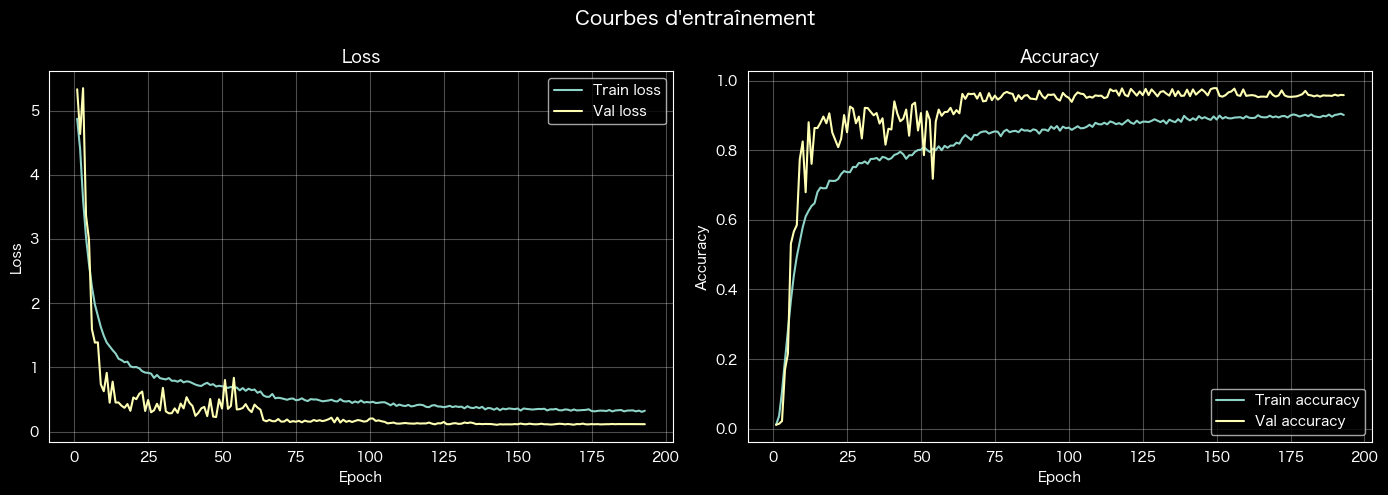


Train acc: 0.9015 | Val acc: 0.9585 | Gap: 5.7%


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history["loss"]) + 1)

# Loss
ax1.plot(epochs_range, history.history["loss"], label="Train loss")
ax1.plot(epochs_range, history.history["val_loss"], label="Val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, history.history["accuracy"], label="Train accuracy")
ax2.plot(epochs_range, history.history["val_accuracy"], label="Val accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Courbes d'entraînement", fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Gap train/val
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
gap = abs(final_train_acc - final_val_acc) * 100
print(f"\nTrain acc: {final_train_acc:.4f} | Val acc: {final_val_acc:.4f} | Gap: {gap:.1f}%")
if gap > 10:
    print("⚠️  Gap train/val > 10% — risque d'overfitting")

## 9. Évaluation sur le test set

In [9]:
# Évaluation globale
y_test_soft = to_soft_labels(y_test)
test_loss, test_acc = model.evaluate(X_test, y_test_soft, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# Top-5 accuracy
y_pred_proba = model.predict(X_test, verbose=0)
top5 = np.mean([y_test[i] in np.argsort(y_pred_proba[i])[-5:] for i in range(len(y_test))])
print(f"Top-5 accuracy: {top5:.4f}")

# Accuracy par type
y_pred = np.argmax(y_pred_proba, axis=1)
hira_mask = y_test < 48
kata_mask = y_test >= 48
hira_acc = np.mean(y_pred[hira_mask] == y_test[hira_mask])
kata_acc = np.mean(y_pred[kata_mask] == y_test[kata_mask])
print(f"\nHiragana accuracy: {hira_acc:.4f}")
print(f"Katakana accuracy: {kata_acc:.4f}")

Test loss: 0.1363
Test accuracy: 0.9535
Top-5 accuracy: 0.9900

Hiragana accuracy: 0.9453
Katakana accuracy: 0.9786


## 10. Matrice de confusion

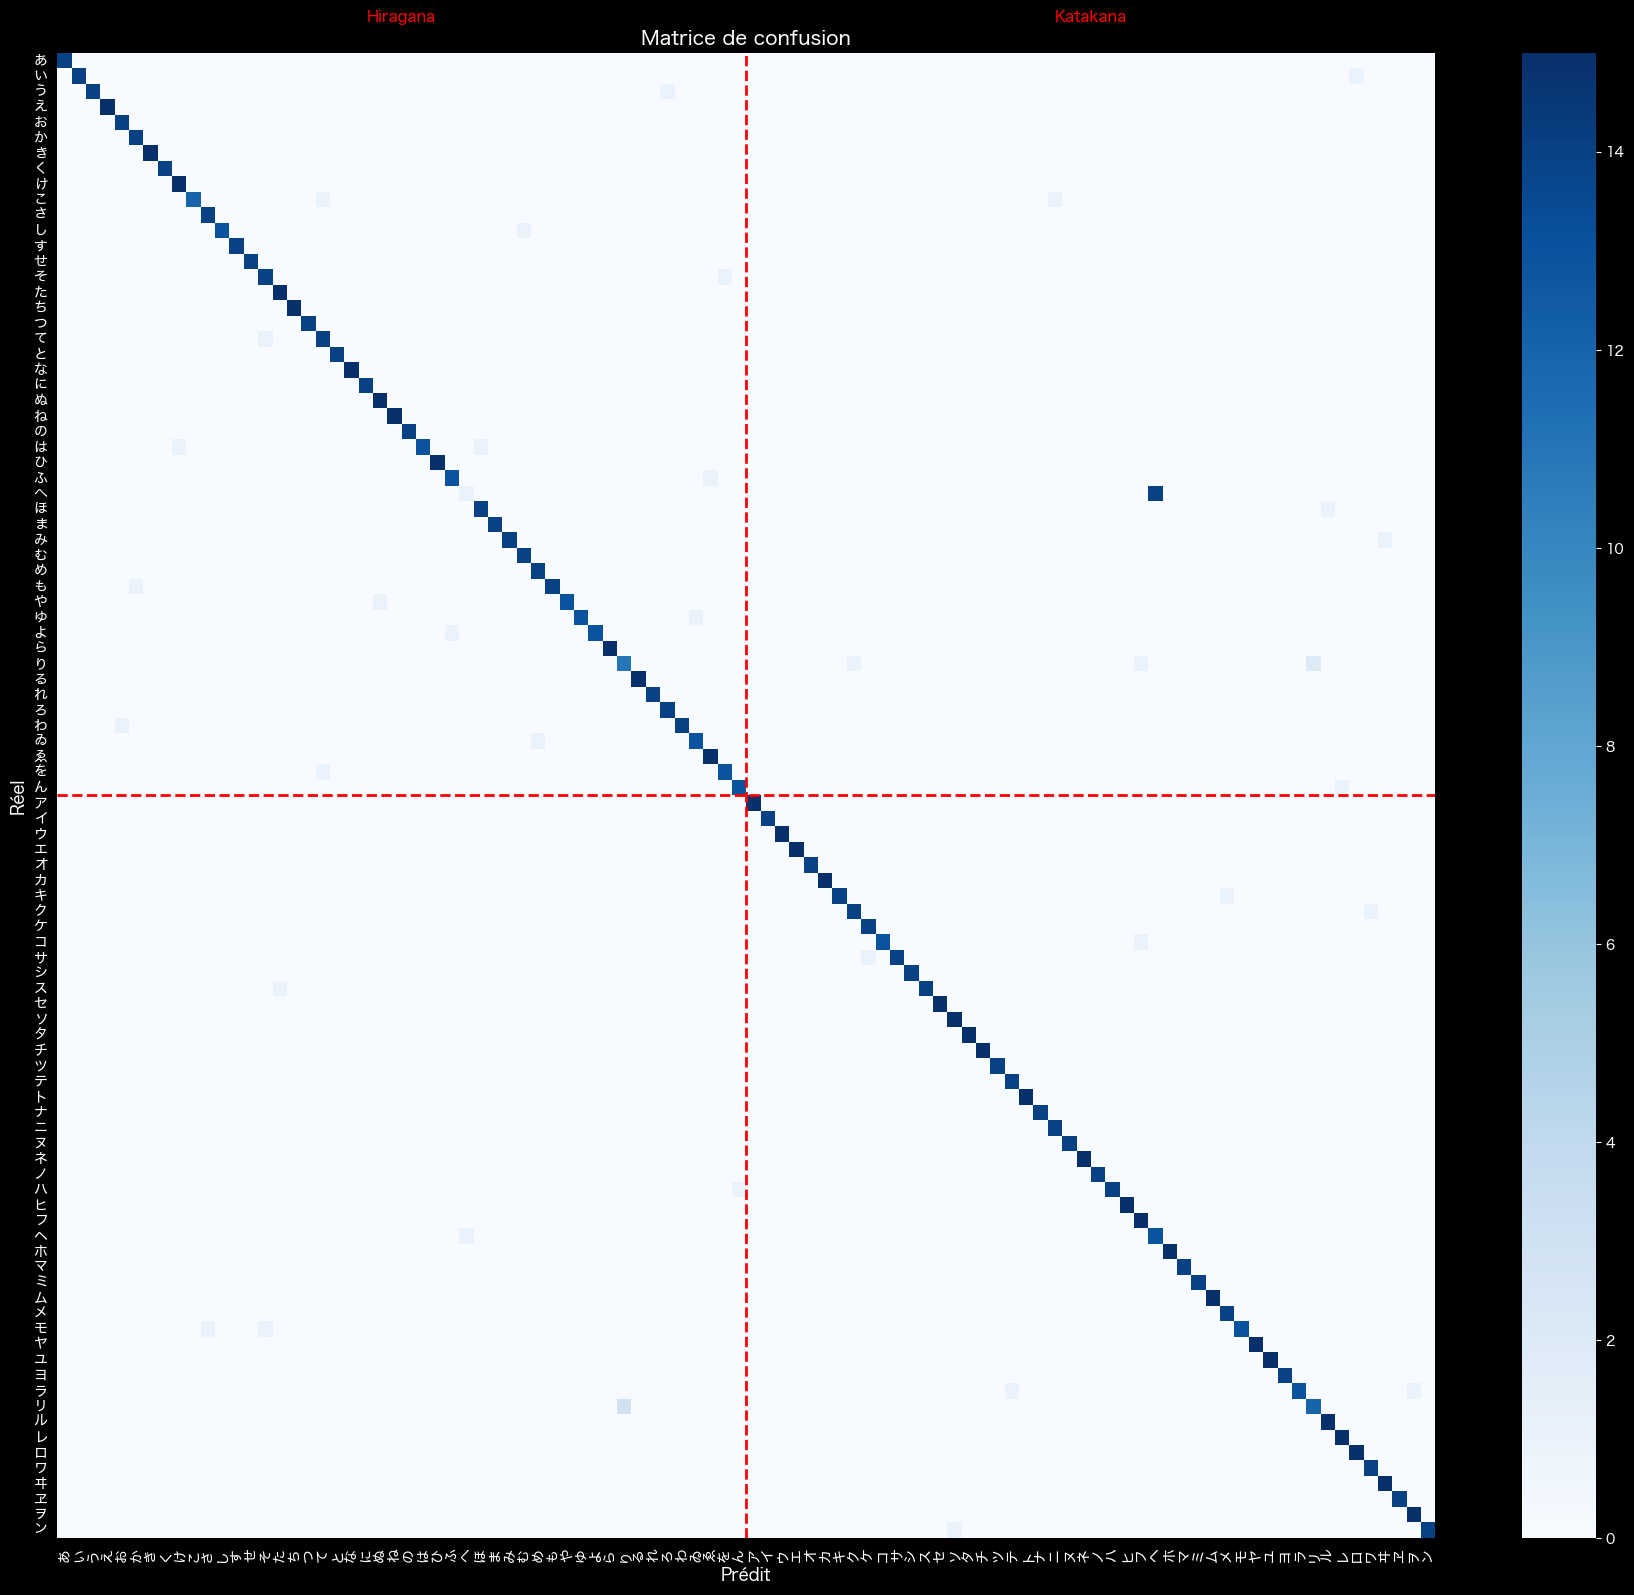

In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm, ax=ax, cmap="Blues", fmt="d",
            xticklabels=[label_info[i]["kana"] for i in range(NUM_CLASSES)],
            yticklabels=[label_info[i]["kana"] for i in range(NUM_CLASSES)])
ax.set_xlabel("Prédit", fontsize=12)
ax.set_ylabel("Réel", fontsize=12)
ax.set_title("Matrice de confusion", fontsize=14)

# Ligne séparatrice hiragana / katakana
ax.axhline(y=48, color="red", linewidth=2, linestyle="--")
ax.axvline(x=48, color="red", linewidth=2, linestyle="--")
ax.text(24, -2, "Hiragana", ha="center", fontsize=11, color="red")
ax.text(72, -2, "Katakana", ha="center", fontsize=11, color="red")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Top 10 classes les plus difficiles

Top 10 classes les plus difficiles (recall le plus bas) :

 Idx  Kana  Romaji    Type          Recall
--------------------------------------------
  28     へ  he        hiragana       6.67%
  39     り  ri        hiragana      73.33%
  87     リ  ri        katakana      80.00%
   9     こ  ko        hiragana      85.71%
  25     は  ha        hiragana      86.67%
  86     ラ  ra        katakana      86.67%
  82     モ  mo        katakana      86.67%
  35     や  ya        hiragana      92.86%
  36     ゆ  yu        hiragana      92.86%
  37     よ  yo        hiragana      92.86%


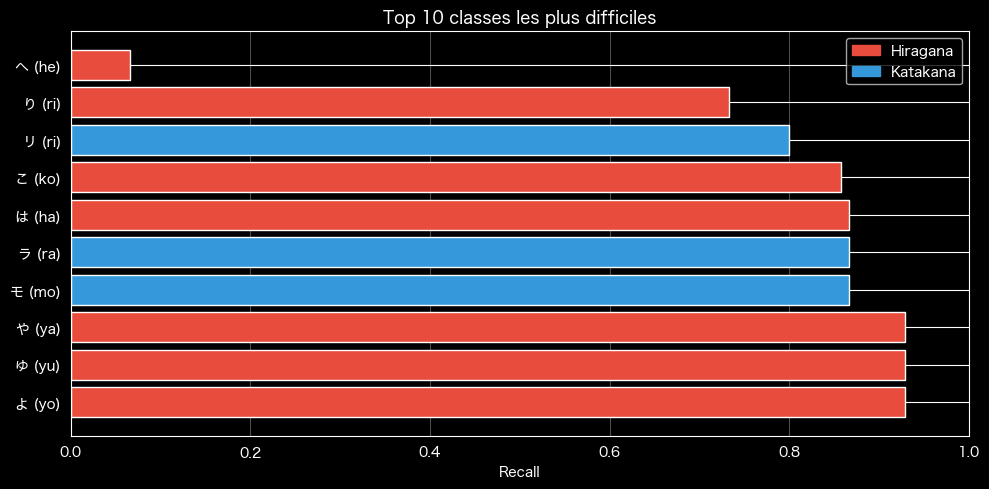

In [11]:
# Recall par classe
per_class_recall = cm.diagonal() / cm.sum(axis=1).clip(min=1)

# Top 10 pires
worst_idx = np.argsort(per_class_recall)[:10]

print("Top 10 classes les plus difficiles (recall le plus bas) :\n")
print(f"{'Idx':>4s}  {'Kana':>4s}  {'Romaji':<8s}  {'Type':<10s}  {'Recall':>8s}")
print("-" * 44)
for idx in worst_idx:
    info = label_info[idx]
    print(f"{idx:4d}  {info['kana']:>4s}  {info['romaji']:<8s}  {info['type']:<10s}  {per_class_recall[idx]:8.2%}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
bar_labels = [f"{label_info[i]['kana']} ({label_info[i]['romaji']})" for i in worst_idx]
bar_values = [per_class_recall[i] for i in worst_idx]
colors = ["#e74c3c" if label_info[i]["type"] == "hiragana" else "#3498db" for i in worst_idx]
ax.barh(bar_labels[::-1], bar_values[::-1], color=colors[::-1])
ax.set_xlabel("Recall")
ax.set_title("Top 10 classes les plus difficiles")
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3, axis="x")

# Légende
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#e74c3c", label="Hiragana"), Patch(color="#3498db", label="Katakana")])

plt.tight_layout()
plt.savefig(PLOTS_DIR / "hardest_classes.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Exemples d'erreurs

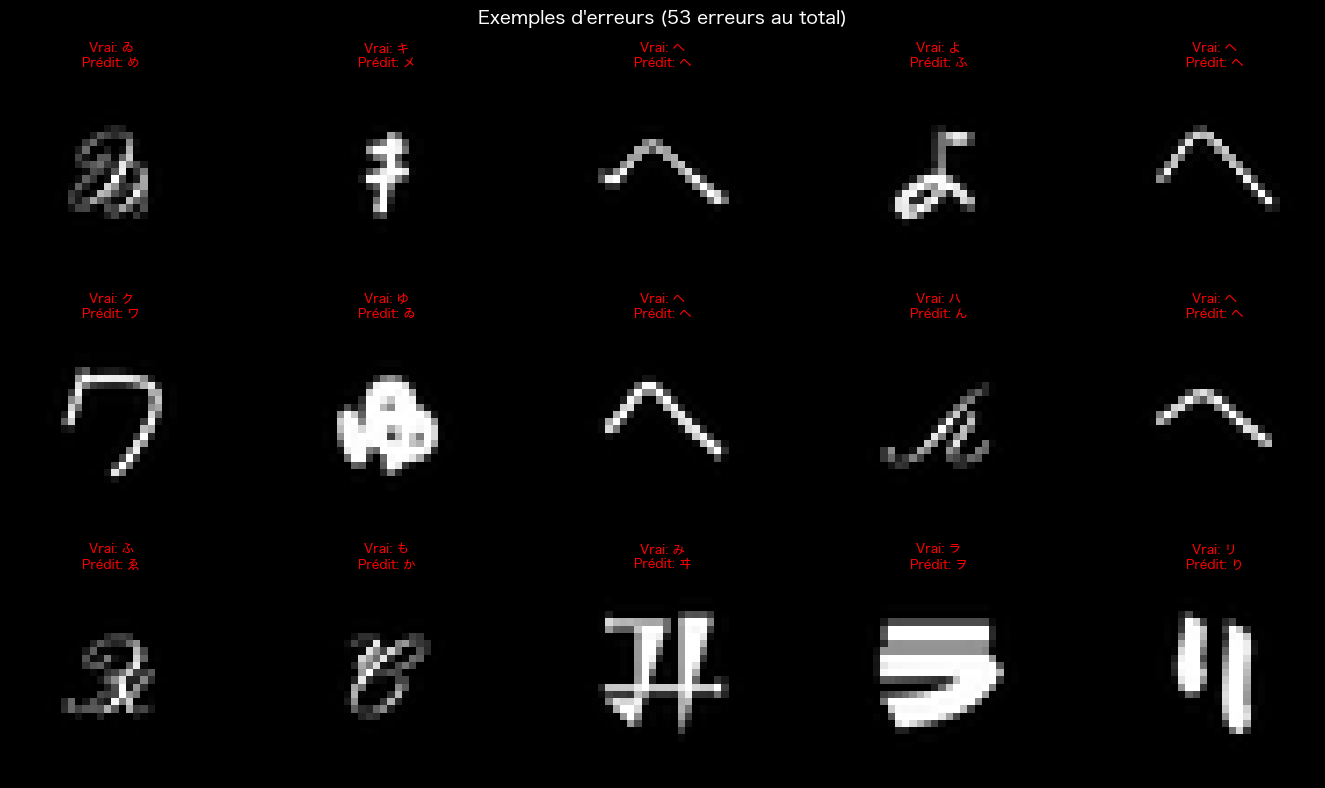

In [12]:
# Afficher des samples mal classés
errors = np.where(y_pred != y_test)[0]
n_show = min(15, len(errors))

if n_show == 0:
    print("Aucune erreur sur le test set !")
else:
    fig, axes = plt.subplots(3, 5, figsize=(14, 8))
    for ax, idx in zip(axes.flat, errors[:n_show]):
        ax.imshow(X_test[idx, :, :, 0], cmap="gray")
        true_info = label_info[y_test[idx]]
        pred_info = label_info[y_pred[idx]]
        ax.set_title(f"Vrai: {true_info['kana']}\nPrédit: {pred_info['kana']}", fontsize=9, color="red")
        ax.axis("off")
    # Masquer les axes vides
    for ax in axes.flat[n_show:]:
        ax.axis("off")
    plt.suptitle(f"Exemples d'erreurs ({len(errors)} erreurs au total)", fontsize=13)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "error_samples.png", dpi=150, bbox_inches="tight")
    plt.show()

## 13. Sauvegarde du modèle

In [13]:
# Le meilleur modèle est déjà sauvé via ModelCheckpoint
# On sauvegarde aussi le modèle final
model.save(str(MODELS_DIR / "final_model.keras"))

print(f"Modèles sauvegardés dans {MODELS_DIR}/")
print(f"  best_model.keras  — meilleure val_accuracy pendant l'entraînement")
print(f"  final_model.keras — état final après EarlyStopping")
print(f"\nPlots sauvegardés dans {PLOTS_DIR}/")
print(f"  training_curves.png")
print(f"  confusion_matrix.png")
print(f"  hardest_classes.png")
print(f"  error_samples.png")

Modèles sauvegardés dans models/
  best_model.keras  — meilleure val_accuracy pendant l'entraînement
  final_model.keras — état final après EarlyStopping

Plots sauvegardés dans plots/
  training_curves.png
  confusion_matrix.png
  hardest_classes.png
  error_samples.png
